In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

# Note: These functions are provided for your convenience, use them where needed
from supplied import pflat, plot_camera, rital, camera_center_and_axis
from helpers import estimate_F_DLT, enforce_essential, convert_E_to_F, enforce_fundamental, estimate_E_robust
from helpers import triangulate_3D_point_DLT, extract_P_from_E, compute_epipolar_errors, estimate_T_robust, estimate_T_DLT
#from helpers import estimate_E_and_H_robust
from project_helpers import get_dataset_info
from pathlib import Path

from cv2 import SIFT_create, cvtColor, COLOR_RGB2GRAY, FlannBasedMatcher, drawMatchesKnn

np.random.seed(1)

In [2]:
def SIFT_feature_extraction(cwd, img_names):
    im_list = []
    keypoint_list = []
    descriptor_list = []

    rgb2gray = lambda img: cvtColor(img, COLOR_RGB2GRAY)
    sift = SIFT_create(contrastThreshold=0.02, edgeThreshold=10, nOctaveLayers=3)

    # load images in greyscale
    for j, name in enumerate(img_names):
        print((f'./{name}'))
        #im = cv2.imread(f'{cwd}\{name}', cv2.IMREAD_GRAYSCALE)
        im = (plt.imread(f'./{name}') * 255).astype('uint8')#f'{cwd}\{name}'

        keypoints, descriptors = sift.detectAndCompute(rgb2gray(im),None)
        # compute keypoints and descriptors for both images
        #keypoints, descriptors = sift.detectAndCompute(im, None)
        im_list.append(im)
        keypoint_list.append(keypoints)
        descriptor_list.append(descriptors)
    
    return im_list, keypoint_list, descriptor_list


In [3]:
def find_good_matches(desc1, desc2, keypoints1, keypoints2, ratio_threshold):
    '''
    Docstring for find_good_matches
    
    returns good matches made by SIFT with lowe ratio 0.75

    x1, x2 in pixel coordinates
    '''
    bf = cv2.BFMatcher(cv2.NORM_L2)
    matches12 = bf.knnMatch(desc1, desc2, k=2)
    matches21 = bf.knnMatch(desc2, desc1, k=2)

    good12 = [m for m,n in matches12 if m.distance < ratio_threshold*n.distance]
    good21 = [m for m,n in matches21 if m.distance < ratio_threshold*n.distance]

    # Mutual matches
    good_matches = []
    for m in good12:
        if any(m.trainIdx == mm.queryIdx and m.queryIdx == mm.trainIdx for mm in good21):
            good_matches.append(m)
    

    x1 = np.array([keypoints1[m.queryIdx].pt for m in good_matches]).T
    x2 = np.array([keypoints2[m.trainIdx].pt for m in good_matches]).T
    return x1, x2, good_matches, desc2

In [4]:
def save_in_mat(variables, file_name, variable_names):
    from scipy.io import savemat

    savemat(
        file_name,
        dict(zip(variable_names, variables)
        )
    )

In [5]:
def draw_keypoints(im1, im2, keypoints1, keypoints2):
    im1_kp = cv2.drawKeypoints(im1, keypoints1, None,
                           flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    im2_kp = cv2.drawKeypoints(im2, keypoints2, None,
                           flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    fig, (ax1, ax2) = plt.subplots(1,2)
    
    ax1.imshow(im1_kp)
    ax1.set_title("Image 1 keypoints")

    ax2.imshow(im2_kp)
    ax2.set_title("Image 2 keypoints")

    plt.show()

Initilize global variables and get SIFT points 

In [6]:
  # Choose params
params = dict(
        dataset=3,
        inlier_threshold_E=0.6, 
        inlier_threshold_T=0.6,
        lowe_ratio=0.75
    )

file_names = []

# initialize K and pixel threshold (given in assigement)
K, img_names, init_pair, pixel_threshold = get_dataset_info(params['dataset'])
K_inv = np.linalg.inv(K)

# Pixel threshold for RANSAC (given in assignement)
eps_K_norm = pixel_threshold / K[0,0]
print(f'eps_K_norm = {eps_K_norm}')

# Initialize P1 3x4 [I | 0]
R1 = np.diag([1, 1, 1])
T1 = np.array([0,0,0]).T
P_init = np.hstack((R1, T1.reshape(3,1)))
print(P_init)

# Initialize file path
cwd = Path.cwd()
print(cwd)

# extracting features from images in SIFT
im, keypoints, descriptors = SIFT_feature_extraction(cwd, img_names)


print(f'number of keypoint objects = {len(keypoints)}')
print(f'number of descriptor objects = {len(descriptors)}')
print(f'number of images = {len(im)}')
print(f'Init pair = ', init_pair)

eps_K_norm = 0.0004204305208533539
[[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]]
c:\Users\pontu\Desktop\CHALMERS\PROJECTS_REPO\Projects\CV_Project\data_2025
./data/3/DSC_0001.JPG
./data/3/DSC_0002.JPG
./data/3/DSC_0003.JPG
./data/3/DSC_0004.JPG
./data/3/DSC_0005.JPG
./data/3/DSC_0006.JPG
./data/3/DSC_0007.JPG
./data/3/DSC_0008.JPG
./data/3/DSC_0009.JPG
./data/3/DSC_0010.JPG
./data/3/DSC_0011.JPG
./data/3/DSC_0012.JPG
number of keypoint objects = 12
number of descriptor objects = 12
number of images = 12
Init pair =  [4, 7]


Extract init pair matches from SIFT that triangulate the initial 3D points

Extract matches from SIFT for a general image pairs

In [7]:
def extract_good_matches(im1, im2):
    '''
    General match extractor
    input: image index
    output: x1 and x2 correspondances filtered with lowe ratio and the matches between im1 and im2

    '''
    # extracting correspondances from SIFT 
    x1, x2, good_matches, d2 = find_good_matches(descriptors[im1], descriptors[im2], keypoints[im1], keypoints[im2], params['lowe_ratio'])

    print(f'shape of SIFT points from image {im1} and {im2}\n')
    print(f'shape x1 after matching = {x1.shape}')
    print(f'shape x2 after matching = {x2.shape}')

    return x1, x2, good_matches, d2
    

Normalize and homogenize SIFT points

Extract inliers and inlier position in x1 and x2 

In [8]:

def extract_inliers(x1, x2):
    '''
    input: normalized SIFT points

    output: inliers, postions of inliers and estimated E 
    '''

    # Estimate E using RANSAC
    E, inliers, errs, iters, inlier_position = estimate_E_robust(x1, x2, eps_K_norm, params['inlier_threshold_E'], seed=None)
    #E, inliers = estimate_E_and_H_robust(K, x1, x2, 0, 1500, eps_K_norm, essential_matrix=True, homography=True, verbose=False)
    

    # extracting inlier points from RANSAC
    inlier_x1, inlier_x2 = inliers

    print(f'Shape of inlier x1 = {inlier_x1.shape}')
    print(f'Shape of inlier x2 = {inlier_x2.shape}')
    print(f'Shape of inlier position = {inlier_position.shape}')

    assert len(inlier_x1[1]) == sum(inlier_position)
    assert len(inlier_position) == len(x1[1])

    return E, inlier_x1, inlier_x2, inlier_position

Filtering descriptors from im "init_pair[1]" to only include descriptors that were inliers in current inlier search. 

We want to assure that the descriptors for the 3D points that get filtered out are corresponding to the descriptors of the current images descriptor. 

In [9]:
def filter_init_descriptors(good_matches, inlier_position, descriptors_init):
    '''
    input: 
    good matches: matches between image "init_pair[1]" and descriptor of other images
    ie. for a image set of 9 images where 9 is "init_pair[1]", [1, 9], [2, 9], [3, 9], ... and so on.

    inlier_position: position of the inliers based of epipolar constrains between im1 and 9

    output:
    descriptors of im 9 that has passed lowe test and RANSAC
    '''
    # filtering out descriptors in good_matches where the inliers were
    # here we take all the good match indexes between image 1 and 9 and filter the descriptors of 
    # image 9 -> this gives us descriptors of im 9 that pass the lowe ratio test.
    # if inlier_position[0] is true then  that corresponds to that good_matches[0] is an inlier,
    # therefore we add that descriptor to the descriptors that describe all descriptors that pass
    # the lowe ratio test and the RANSAC test. 
    filtered_init_descriptors = [descriptors_init[m.trainIdx] for m, n in zip(good_matches, inlier_position) if n == 1]
    return filtered_init_descriptors

    

Triangulate init pair points 

In [10]:
def triangulate(E, inlier_init_x1, inlier_init_x2, P1, verbose=False, plot=False):
    assert np.allclose(inlier_init_x1[2], 1)
    assert np.allclose(inlier_init_x2[2], 1)

    # Compute Cameras from E / relative rotation P1 P2
    P2_arr = extract_P_from_E(E)
        
    # stating how many inlier points are available
    N = inlier_init_x1.shape[1]

    # initilizing list to store 3D scene points in. 4xNx4.
    X_tot_arr = []

    # initilizing cherialty check list
    count = np.zeros(4)

    # triangulating X from RANSAC inliers
    for idxx, P2 in enumerate(P2_arr):
        X_arr = np.zeros((4, N))
        for p in range(N):
            X = triangulate_3D_point_DLT(inlier_init_x1[:,p], inlier_init_x2[:,p], P1, P2)
            

            X_arr[:,p] = X
            if X[2] < 0 or X[2] > 5000:
                  X_arr[:,p] = np.nan      
            
            # Cherialty check

            P1Xj = P1 @ X
            if P1Xj[2] <= 0:
                continue

            RXt = P2[:, :3] @ X[:3] + P2[:, 3]
            if RXt[2] <= 0:
                continue

            # if positive 
            count[idxx] += 1
            
        X_tot_arr.append(X_arr)    
    
    # cherialty check
    max_position = np.argmax(count)

    # saving correct P2 
    correct_P2 = P2_arr[max_position]
    correct_X = X_tot_arr[max_position]

    if verbose: 
        print('X3', count)
        print('max position', max_position)    

        for idxx, P2 in enumerate(P2_arr):
            Rrrr = P2[:,:-1]
            d = np.linalg.det(Rrrr)
            print('determinant of P2', d)

    if plot:
        fig22 = plt.figure()
        fig22.suptitle('position 1')
        ax22 = fig22.add_subplot(projection="3d")

        #ax1.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
        ax22.scatter(X_tot_arr[0][0], X_tot_arr[0][1], X_tot_arr[0][1], s=1)
        ax22.view_init(elev=-24, azim=-96, roll=179)
        plot_camera(P_init, 1, ax=ax22)
        plot_camera(P2_arr[0], 1, ax=ax22)

        fig222 = plt.figure()
        fig222.suptitle('position 2')
        ax222 = fig222.add_subplot(projection="3d")


        #ax1.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
        ax222.scatter(X_tot_arr[1][0], X_tot_arr[1][1], X_tot_arr[1][1], s=1)
        ax222.view_init(elev=-24, azim=-96, roll=179)
        plot_camera(P_init, 1, ax=ax222)
        plot_camera(P2_arr[1], 1, ax=ax222)

        fig2222 = plt.figure()
        fig2222.suptitle('position 3')
        ax2222 = fig2222.add_subplot(projection="3d")


        #ax1.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
        ax2222.scatter(X_tot_arr[2][0], X_tot_arr[2][1], X_tot_arr[2][1], s=1)
        ax2222.view_init(elev=-24, azim=-96, roll=179)
        plot_camera(P_init, 1, ax=ax2222)
        plot_camera(P2_arr[2], 1, ax=ax2222)

        fig22222 = plt.figure()
        fig22222.suptitle('position 4')
        ax22222 = fig22222.add_subplot(projection="3d")


        #ax1.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
        ax22222.scatter(X_tot_arr[3][0], X_tot_arr[3][1], X_tot_arr[3][1], s=1)
        ax22222.view_init(elev=-24, azim=-96, roll=179)
        plot_camera(P_init, 1, ax=ax22222)
        plot_camera(P2_arr[3], 1, ax=ax22222)

        plt.show()
    return correct_P2, correct_X
    # result from this is:
    # - correct X and correct P for estimated E

Get inliers and 3D points from init pair

[4, 7]
shape of SIFT points from image 4 and 7

shape x1 after matching = (2, 13118)
shape x2 after matching = (2, 13118)


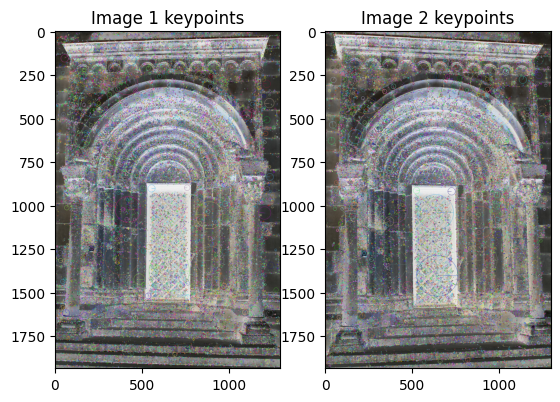

len descriptors init: 40155

len descriptors init_pair[0]: 41728

descriptors_init_pair_2: 40155

shape good_matches_init: (13118,)


In [11]:
first, second = init_pair
#first, second = [1, 2]

print(init_pair)

init_x1, init_x2, good_matches_init, descriptors_init = extract_good_matches(first, second)
draw_keypoints(im[first], im[second], keypoints[first], keypoints[second])

# extract and save the descriptors for the points that gets triangulated
descriptors_init_pair_2 = descriptors[second]

print(f'len descriptors init: {len(descriptors_init)}\n')
print(f'len descriptors init_pair[0]: {len(descriptors[init_pair[0]])}\n')
print(f'descriptors_init_pair_2: {len(descriptors[second])}\n')
print(f'shape good_matches_init: {np.shape(good_matches_init)}')

In [12]:
# restructuring and homogenizing SIFT points
ones = np.ones((1, init_x1.shape[1])) 
x1_h = np.vstack((init_x1, ones)) 
x2_h = np.vstack((init_x2, ones))

# normalizing SIFT points
x1_hn = K_inv @ x1_h 
x2_hn = K_inv @ x2_h


In [13]:

# get inlier pair from init pair
E, inlier_init_x1, inlier_init_x2, inlier_position = extract_inliers(x1_hn, x2_hn)


Shape of inlier x1 = (3, 4410)
Shape of inlier x2 = (3, 4410)
Shape of inlier position = (13118,)


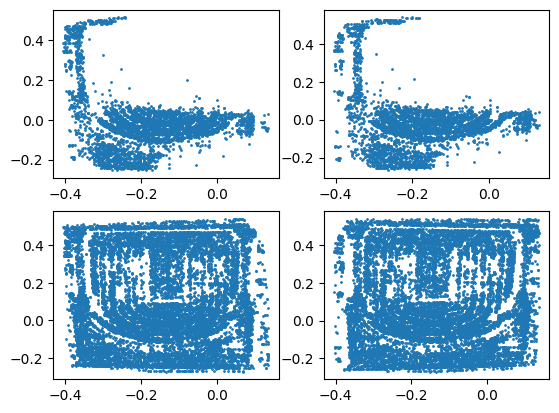

In [14]:
f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2)
ax1.scatter(inlier_init_x1[0], inlier_init_x1[1], s=1) 
ax2.scatter(inlier_init_x2[0], inlier_init_x2[1], s=1) 
ax3.scatter(x1_hn[0], x1_hn[1], s=1) 
ax4.scatter(x2_hn[0], x2_hn[1], s=1) 
plt.show()

In [15]:
# extract descriptors of points in image "init_pair[1]" that gets triangulated
filtered_descriptors = filter_init_descriptors(good_matches_init, inlier_position, descriptors_init_pair_2)

# make filtered descriptors into a np array to match descriptor format
filtered_descriptors = np.array(filtered_descriptors)

print(len(init_x1[1]))
print(len(inlier_init_x1[1]))
assert len(filtered_descriptors) == len(inlier_init_x1[1])
assert len(filtered_descriptors) == len(inlier_init_x2[1])


13118
4410


In [16]:
# put in an E and inlier points and get out P2 and X for those points
correct_P2_init, correct_X_init = triangulate(E, inlier_init_x1, inlier_init_x2, P_init, verbose=True)



X3 [   0.    0.    0. 4410.]
max position 3
determinant of P2 1.0000000000000004
determinant of P2 1.0000000000000004
determinant of P2 1.0000000000000002
determinant of P2 1.0000000000000002


Vizualize 3D points with estimated P

[[ 0.98465017 -0.02874289 -0.17215658  0.99652124]
 [ 0.03177866  0.99938382  0.01490319 -0.0403493 ]
 [ 0.17162213 -0.02014534  0.98495686  0.07292021]]
[[-1.95194001 -1.9142327  -1.92690382 ...  0.75221316  0.73904303
   0.77153354]
 [ 1.67687434  1.83079563  1.74111166 ... -0.31885649  0.1693329
  -0.22676275]
 [ 4.83501566  4.74234268  4.77537641 ...  5.78799754  5.61145909
   5.7585992 ]
 [ 1.          1.          1.         ...  1.          1.
   1.        ]]


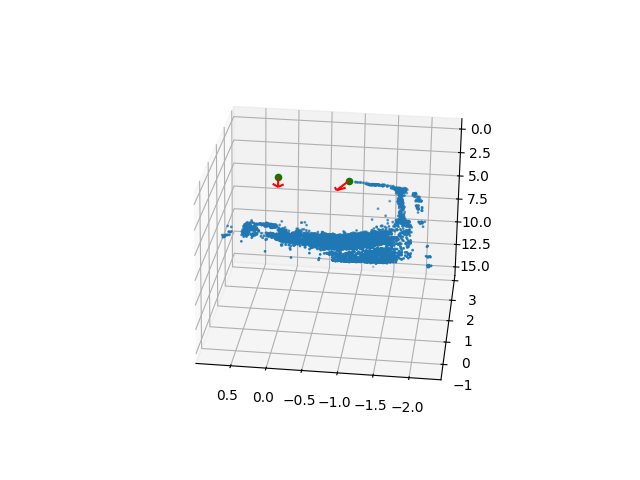

In [17]:
print(correct_P2_init)
print(correct_X_init)

%matplotlib widget  

fig1 = plt.figure()
ax1 = fig1.add_subplot(projection="3d")


#ax1.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
ax1.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
ax1.view_init(elev=-24, azim=-96, roll=179)
plot_camera(P_init, 1, ax=ax1)
plot_camera(correct_P2_init, 1, ax=ax1)


plt.show()

Calculate relative rotations of all images

In [18]:
print(len(im))

# initialize list for storing camera matrices for relative rotations
P_relative_rotation = []
x1_final = []
x2_final = []
X_inliers = []
#P_relative_rotation.append(P_init)

for idxx, img in enumerate(im):
    if idxx == len(im)-1:
        continue
    else:
        x1, x2, _, _ = extract_good_matches(idxx, idxx+1)

        # restructuring and homogenizing SIFT points
        ones = np.ones((1, x1.shape[1])) 
        rel_x1_h = np.vstack((x1, ones)) 
        rel_x2_h = np.vstack((x2, ones))

        # normalizing SIFT points
        rel_x1_hn = K_inv @ rel_x1_h 
        rel_x2_hn = K_inv @ rel_x2_h

        # get E and inlier pair from im idx, idx+1 pair
        E, rel_inlier_x1, rel_inlier_x2, _ = extract_inliers(rel_x1_hn, rel_x2_hn)

        correct_P2, X_inlier = triangulate(E, rel_inlier_x1, rel_inlier_x2, P_init, verbose=True)
        x1_final.append(rel_inlier_x1)
        x2_final.append(rel_inlier_x2)
        X_inliers.append(X_inlier)
        print(idxx)
        P_relative_rotation.append(correct_P2)




12
shape of SIFT points from image 0 and 1

shape x1 after matching = (2, 18016)
shape x2 after matching = (2, 18016)
Shape of inlier x1 = (3, 12563)
Shape of inlier x2 = (3, 12563)
Shape of inlier position = (18016,)
X3 [    0.     0. 12563.     0.]
max position 2
determinant of P2 0.9999999999999998
determinant of P2 0.9999999999999998
determinant of P2 0.9999999999999998
determinant of P2 0.9999999999999998
0
shape of SIFT points from image 1 and 2

shape x1 after matching = (2, 16883)
shape x2 after matching = (2, 16883)
Shape of inlier x1 = (3, 10161)
Shape of inlier x2 = (3, 10161)
Shape of inlier position = (16883,)
X3 [    0.     0. 10161.     0.]
max position 2
determinant of P2 0.9999999999999998
determinant of P2 0.9999999999999998
determinant of P2 0.9999999999999998
determinant of P2 0.9999999999999998
1
shape of SIFT points from image 2 and 3

shape x1 after matching = (2, 18363)
shape x2 after matching = (2, 18363)
Shape of inlier x1 = (3, 7234)
Shape of inlier x2 = (3, 

[array([[ 9.97900310e-01, -2.42827631e-02, -6.00442982e-02,
         9.96504484e-01],
       [ 2.41894852e-02,  9.99704792e-01, -2.27998148e-03,
         3.15637966e-02],
       [ 6.00819369e-02,  8.22753566e-04,  9.98193110e-01,
         7.73468821e-02]]), array([[ 0.99682434, -0.02568829, -0.07537471,  0.98254552],
       [ 0.02337569,  0.99923336, -0.03140501, -0.02886204],
       [ 0.07612366,  0.02954334,  0.99666061, -0.18376966]]), array([[ 0.9973983 , -0.02297529, -0.06832836,  0.96662816],
       [ 0.02310917,  0.99973226,  0.00116946,  0.18120242],
       [ 0.0682832 , -0.00274542,  0.9976622 ,  0.1810958 ]]), array([[ 0.99805635, -0.01984879, -0.05907235,  0.99012102],
       [ 0.02159738,  0.99934284,  0.02911101,  0.02605227],
       [ 0.05845571, -0.03033023,  0.99782915,  0.13777389]]), array([[ 9.97379892e-01, -1.06310351e-02, -7.15564972e-02,
         9.97731797e-01],
       [ 1.06908641e-02,  9.99942748e-01,  4.53158451e-04,
        -4.26336202e-02],
       [ 7.154758

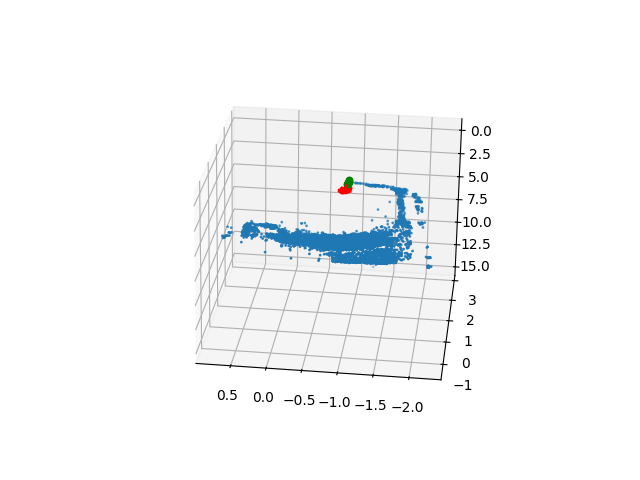

In [19]:
print(P_relative_rotation)
#print(correct_P2_init)

fig3 = plt.figure()
ax3 = fig3.add_subplot(projection="3d")

ax3.scatter(correct_X_init[0], correct_X_init[1], correct_X_init[2], s=1)
for p in P_relative_rotation:
    plot_camera(p, 1, ax=ax3)
ax3.view_init(elev=-24, azim=-96, roll=179)


plt.show()

Calculate absolute rotations

Calculate T

In [20]:
# initialize list for storing roation matrices for absolute rotations
R_absolute_rotation = []
R_absolute_rotation.append(R1)
# calculate absolute rotations using relative rotations
for iter, relative_P in enumerate(P_relative_rotation):
    if iter == len(P_relative_rotation):
        continue
    Ri = R_absolute_rotation[-1]
    curr_P = P_relative_rotation[iter]
    R2 = curr_P[:,:-1]
    U, _, VT = np.linalg.svd(R2, full_matrices=False)
    R2 = U @ VT
    Rj = R2 @ Ri
    R_absolute_rotation.append(Rj)

    print(f'should be 1 and is = {np.linalg.det(R2)}')          # should be very close to +1
    print(f'should be very small and is = {np.linalg.norm(R2.T @ R2 - np.eye(3))}')  # should be very small

    

print(f'R_absolute_rotation = {R_absolute_rotation}')

for RR in R_absolute_rotation:
    print(f'should be 1 and is = {np.linalg.det(RR)}') 
    print(f'should be very small and is = {np.linalg.norm(RR.T @ RR - np.eye(3))}')  


should be 1 and is = 1.0
should be very small and is = 3.0305029980599564e-16
should be 1 and is = 1.0000000000000009
should be very small and is = 1.5755014201138608e-15
should be 1 and is = 0.9999999999999998
should be very small and is = 4.559179043664697e-16
should be 1 and is = 0.9999999999999998
should be very small and is = 3.767158182810318e-16
should be 1 and is = 1.0000000000000002
should be very small and is = 5.556305758907578e-16
should be 1 and is = 1.0
should be very small and is = 2.592866304860885e-16
should be 1 and is = 0.9999999999999998
should be very small and is = 5.3430326816575e-16
should be 1 and is = 1.0000000000000004
should be very small and is = 6.783537289013456e-16
should be 1 and is = 0.9999999999999997
should be very small and is = 6.110531808720907e-16
should be 1 and is = 1.0
should be very small and is = 1.0345646232310673e-15
should be 1 and is = 1.0000000000000002
should be very small and is = 5.073227408001705e-16
R_absolute_rotation = [array([[1

In [21]:
# rotate X 
if init_pair[0] != 0:
    world_coordinate_X = R_absolute_rotation[init_pair[0]].T @ correct_X_init[:3, :] 
else: 
    world_coordinate_X = correct_X_init[:3, :] 

assert len(world_coordinate_X[1]) == len(inlier_init_x1[1])

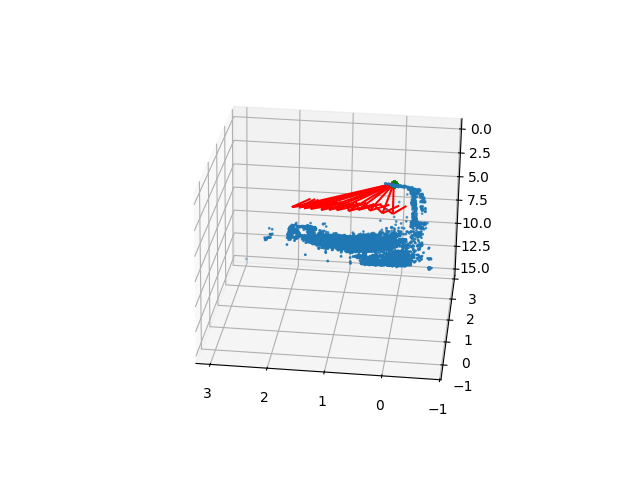

In [22]:
fig4 = plt.figure()
ax4 = fig4.add_subplot(projection="3d")

ax4.scatter(world_coordinate_X[0], world_coordinate_X[1], world_coordinate_X[2], s=1)
ax4.view_init(elev=-24, azim=-96, roll=179)
t = T1
for r in R_absolute_rotation:
    p = np.hstack((r, T1.reshape(3,1)))
    plot_camera(p, 3, ax=ax4)
    
plt.show()

In [23]:

def calculate_one_T(filtered_descriptors, desc, R, keypoints, w_c_X, verbose=False):

    bf = cv2.BFMatcher(cv2.NORM_L2)

    # check matches between every descriptor and 3D descriptor 9 
    matches = bf.knnMatch(filtered_descriptors, desc, k=2)

    xs = np.zeros((2,len(matches)))
    Xs = np.zeros((3,len(matches)))

    for k, (m, n) in enumerate(matches):
        if m.distance < 0.75 * n.distance:
            X_j = w_c_X[:, m.queryIdx]
            x_i = keypoints[m.trainIdx].pt
            xs[:, k] = x_i
            Xs[:, k] = X_j
            
    # homogenize and normalize xs
    o = np.ones(xs.shape[1])
    xsh = np.vstack((xs, o))
    xshn = K_inv @ xsh

    # homogenize Xs
    o = np.ones(Xs.shape[1])
    Xsh = np.vstack((Xs, o))
    
    if verbose:
        print(f'xshn = {xshn}')
        print(f'Xsh = {Xsh}')

    # cherialty check
    assert min(Xs[2]) >= 0

    # estimate T 
    T, inliers, errs, iters = estimate_T_robust(xshn, Xsh, R, 3*eps_K_norm, 0.8)
    return T, xshn


In [24]:

# Initialize list for storing T
T_absolute = []
inliers_T = []
#T_absolute.append(T1)

assert world_coordinate_X.shape[1] == filtered_descriptors.shape[0]

print(filtered_descriptors.shape[0])

for idx, desc in enumerate(descriptors):
    if idx == len(im):
        continue
    else:
        current_camera_rotation = R_absolute_rotation[idx]
        T, xsh = calculate_one_T(filtered_descriptors, desc, current_camera_rotation, keypoints[idx], world_coordinate_X, verbose=True)
        inliers_T.append(xsh) 
        T_absolute.append(T)

number_of_Ts = len(T_absolute)
print(f'number of T:s = {number_of_Ts}')
for nr in range(number_of_Ts):
    print(f'T = {T_absolute[nr].reshape(3,1)}')



4410
xshn = [[-0.40697674 -0.40697674 -0.40697674 ... -0.40697674  0.13091571
  -0.40697674]
 [-0.27243898 -0.27243898 -0.27243898 ... -0.27243898  0.00867559
  -0.27243898]
 [ 1.          1.          1.         ...  1.          1.
   1.        ]]
Xsh = [[0.         0.         0.         ... 0.         2.17583255 0.        ]
 [0.         0.         0.         ... 0.         0.02845733 0.        ]
 [0.         0.         0.         ... 0.         5.22764518 0.        ]
 [1.         1.         1.         ... 1.         1.         1.        ]]
inlier goal = 3528.0


c:\Users\pontu\Desktop\CHALMERS\PROJECTS_REPO\Projects\CV_Project\data_2025\helpers.py:316: RuntimeWarning: invalid value encountered in divide
  x_tilde = x_tilde/x_tilde[-1]


xshn = [[-0.40697674 -0.40697674 -0.36180162 ... -0.40697674 -0.40697674
  -0.40697674]
 [-0.27243898 -0.27243898  0.35177846 ... -0.27243898 -0.27243898
  -0.27243898]
 [ 1.          1.          1.         ...  1.          1.
   1.        ]]
Xsh = [[ 0.          0.         -0.45268909 ...  0.          0.
   0.        ]
 [ 0.          0.          1.85827828 ...  0.          0.
   0.        ]
 [ 0.          0.          5.08827303 ...  0.          0.
   0.        ]
 [ 1.          1.          1.         ...  1.          1.
   1.        ]]
inlier goal = 3528.0
xshn = [[-0.40697674 -0.39130768 -0.39131143 ... -0.40697674  0.12412559
   0.12686393]
 [-0.27243898  0.34079286  0.32056    ... -0.27243898 -0.01980406
  -0.09228889]
 [ 1.          1.          1.         ...  1.          1.
   1.        ]]
Xsh = [[ 0.         -0.44046484 -0.45268909 ...  0.          2.17583255
   2.20719802]
 [ 0.          1.94674035  1.85827828 ...  0.          0.02845733
  -0.37071887]
 [ 0.          5.05194084 

Put together camereras 

In [25]:
# initialize list for storing final P
final_P = []
#final_P.append(P1)

for idx, (R_abs, T_abs) in enumerate(zip(R_absolute_rotation,T_absolute)):
    P = np.hstack((R_abs, T_abs.reshape(3,1)))
    final_P.append(P)

print(f'final_P[1] = \n {final_P[1]}')
print(f'final_R[1] = \n {R_absolute_rotation[1]}')
print(f'final_T[1] = \n {T_absolute[1].reshape(3,1)}')
print(f'final_P = \n {final_P}')


final_P[1] = 
 [[ 9.97900310e-01 -2.42827631e-02 -6.00442982e-02 -1.09663713e+00]
 [ 2.41894852e-02  9.99704792e-01 -2.27998148e-03 -1.47961287e-02]
 [ 6.00819369e-02  8.22753566e-04  9.98193110e-01  1.75055830e-01]]
final_R[1] = 
 [[ 9.97900310e-01 -2.42827631e-02 -6.00442982e-02]
 [ 2.41894852e-02  9.99704792e-01 -2.27998148e-03]
 [ 6.00819369e-02  8.22753566e-04  9.98193110e-01]]
final_T[1] = 
 [[-1.09663713]
 [-0.01479613]
 [ 0.17505583]]
final_P = 
 [array([[ 1.        ,  0.        ,  0.        , -1.44830413],
       [ 0.        ,  1.        ,  0.        ,  0.00900268],
       [ 0.        ,  0.        ,  1.        ,  0.2519527 ]]), array([[ 9.97900310e-01, -2.42827631e-02, -6.00442982e-02,
        -1.09663713e+00],
       [ 2.41894852e-02,  9.99704792e-01, -2.27998148e-03,
        -1.47961287e-02],
       [ 6.00819369e-02,  8.22753566e-04,  9.98193110e-01,
         1.75055830e-01]]), array([[ 0.98958127, -0.04994837, -0.13503356, -3.45969247],
       [ 0.04561067,  0.99834491, -0.

[array([[ 1.        ,  0.        ,  0.        , -1.44830413],
       [ 0.        ,  1.        ,  0.        ,  0.00900268],
       [ 0.        ,  0.        ,  1.        ,  0.2519527 ]]), array([[ 9.97900310e-01, -2.42827631e-02, -6.00442982e-02,
        -1.09663713e+00],
       [ 2.41894852e-02,  9.99704792e-01, -2.27998148e-03,
        -1.47961287e-02],
       [ 6.00819369e-02,  8.22753566e-04,  9.98193110e-01,
         1.75055830e-01]]), array([[ 0.98958127, -0.04994837, -0.13503356, -3.45969247],
       [ 0.04561067,  0.99834491, -0.03503007, -2.31341153],
       [ 0.13655976,  0.02850613,  0.99022161,  8.50048421]]), array([[ 0.97662786, -0.07470347, -0.20153764, -0.38085089],
       [ 0.06862656,  0.99695669, -0.03698319, -0.00508817],
       [ 0.20368707,  0.02228798,  0.97878232,  0.01715615]]), array([[ 9.61335210e-01, -9.56632552e-02, -2.58230819e-01,
         6.59556491e-05],
       [ 9.56036035e-02,  9.95336950e-01, -1.28182314e-02,
         7.21405422e-04],
       [ 2.582529

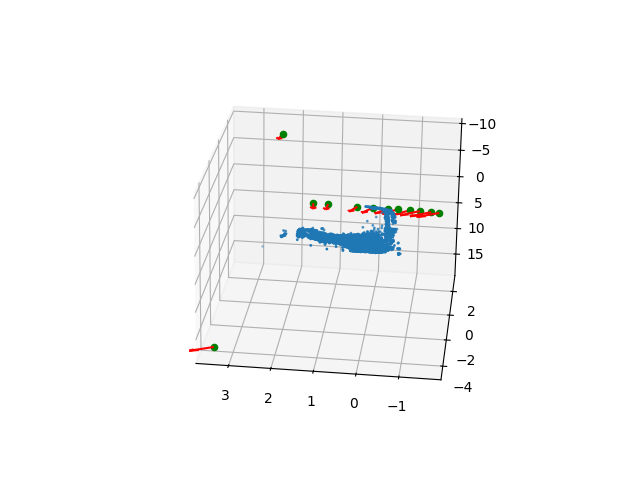

In [26]:
print(final_P)


fig3 = plt.figure()
ax3 = fig3.add_subplot(projection="3d")

R1_world_coordinate_X = world_coordinate_X



ax3.scatter(R1_world_coordinate_X[0], R1_world_coordinate_X[1], R1_world_coordinate_X[2], s=1)

ax3.view_init(elev=-24, azim=-96, roll=179)
for i in final_P:
    plot_camera(i, 1, ax=ax3)


plt.show()

Vizualize

C:\Users\pontu\AppData\Local\Temp\ipykernel_139292\249854633.py:16: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig15 = plt.figure()


(4, 12563)
(4, 10161)
(4, 7234)
(4, 4379)
(4, 11860)
(4, 9830)
(4, 6958)
(4, 11890)
(4, 11924)
(4, 10057)
(4, 8553)


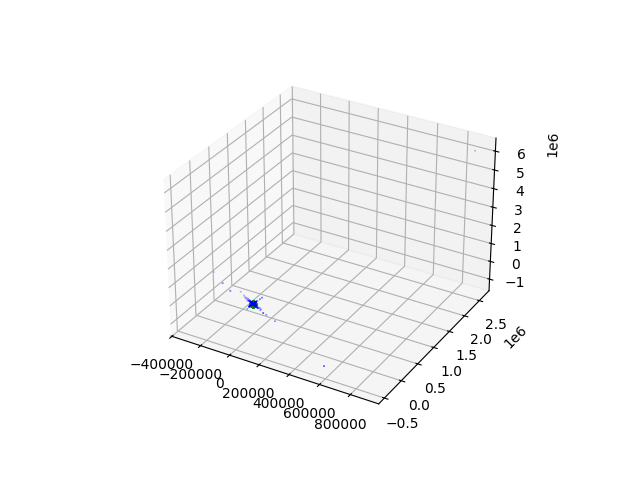

In [46]:
modified_P = []
Xes_tot = []
for idx, (x1, x2) in enumerate(zip(x1_final, x2_final)):
    N = len(x1[1])
    Xes = np.zeros((4, N))
    #if idx == len(im):
    #    continue
    #else:
    cam1 = final_P[idx]
    cam2 = final_P[idx+1]
    for p in range(N):
        X = triangulate_3D_point_DLT(x1[:, p], x2[:, p], cam1, cam2)
        Xes[:,p] = X 
    Xes_tot.append(Xes)

fig15 = plt.figure()
ax15 = fig15.add_subplot(projection="3d")
for k, points in enumerate(final_P):
    cam = final_P[k]
    cam_R = cam[:, :-1]
    cam_T = cam[:, -1]
    cam_R = R_absolute_rotation[init_pair[0]].T @ cam_R
    mod_P = np.hstack((cam_R, cam_T.reshape(3,1)))
    modified_P.append(mod_P)
    plot_camera(mod_P, 1, ax=ax15)

for k, points in enumerate(Xes_tot):
    cam = final_P[init_pair[0]]
    cam_R = cam[:, :-1]
    cam_T = cam[:, -1]
    print(points.shape)
    rot_points = R_absolute_rotation[init_pair[0]] @ points[:3,:]
    
    ax15.scatter(rot_points[0], rot_points[1], rot_points[2], s=0.1, color='b')
    
        

In [28]:
P_relative_rotation = np.stack(P_relative_rotation, axis=0)
R_absolute_rotation = np.stack(R_absolute_rotation, axis=0)
final_P = np.stack(final_P, axis=0)
x1_cell = np.empty(len(x1_final), dtype=object)
x2_cell = np.empty(len(x2_final), dtype=object)

for i in range(len(x1_final)):
    x1_cell[i] = x1_final[i]
    x2_cell[i] = x2_final[i]
print(x1_cell)
print(final_P)


[array([[-0.39682046, -0.39600881, -0.3958903 , ...,  0.12999925,
          0.13004544,  0.13056487],
        [-0.14945193,  0.10841216, -0.13521861, ...,  0.35518291,
          0.36324032,  0.35401677],
        [ 1.        ,  1.        ,  1.        , ...,  1.        ,
          1.        ,  1.        ]], shape=(3, 12563))
 array([[-0.3877596 , -0.37919653, -0.37919653, ...,  0.13345431,
          0.13388967,  0.1339976 ],
        [ 0.5066061 ,  0.44369698,  0.44369698, ..., -0.09103903,
         -0.10058536, -0.15072456],
        [ 1.        ,  1.        ,  1.        , ...,  1.        ,
          1.        ,  1.        ]], shape=(3, 10161))
 array([[-0.39866748, -0.39616218, -0.39592508, ...,  0.13535199,
          0.1354145 ,  0.13654092],
        [-0.26437204, -0.2597339 , -0.0486393 , ...,  0.44801742,
          0.44634412,  0.44344042],
        [ 1.        ,  1.        ,  1.        , ...,  1.        ,
          1.        ,  1.        ]], shape=(3, 7234))
 array([[-0.40548375, -0.4

Dataset X will have elements 
* 'final_P', the estimated cameras [R | t]
* 'x1_final', 'x2_final', the inliers estimated from im i and i+1 using E and RANSAC
* 'P_relative_rotation', estimated relative rotations
*  'R_absolute_rotation' absolute rotations

In [ ]:

#variables = [final_P, x1_cell, x2_cell, P_relative_rotation, R_absolute_rotation]
#variable_names = ['final_P', 'x1_final', 'x2_final', 'P_relative_rotation', 'R_absolute_rotation']
#save_in_mat(variables, 'dataset_3', variable_names)

# save_in_mat(variables, file_name, variable_names):
